              Model                     Condition       MSE ModelUnified
0         GraphSAGE                      Baseline  0.034416    GraphSAGE
1             GUNet                      Baseline  0.035530        GUNet
2               MLP                      Baseline  0.033354          MLP
3          PointNet                      Baseline  0.023221     PointNet
4   GraphSAGEGlobal             PointMAE_centered  0.024444    GraphSAGE
5       GUNetGlobal             PointMAE_centered  0.032747        GUNet
6         MLPGlobal             PointMAE_centered  0.036062          MLP
7    PointNetGlobal             PointMAE_centered  0.032479     PointNet
8   GraphSAGEGlobal    PointMAE_centered_Extruded  0.019979    GraphSAGE
9       GUNetGlobal    PointMAE_centered_Extruded  0.027929        GUNet
10   PointNetGlobal    PointMAE_centered_Extruded  0.038261     PointNet
11  GraphSAGEGlobal              PointMAE_default  0.024977    GraphSAGE
12      GUNetGlobal              PointMAE_default  

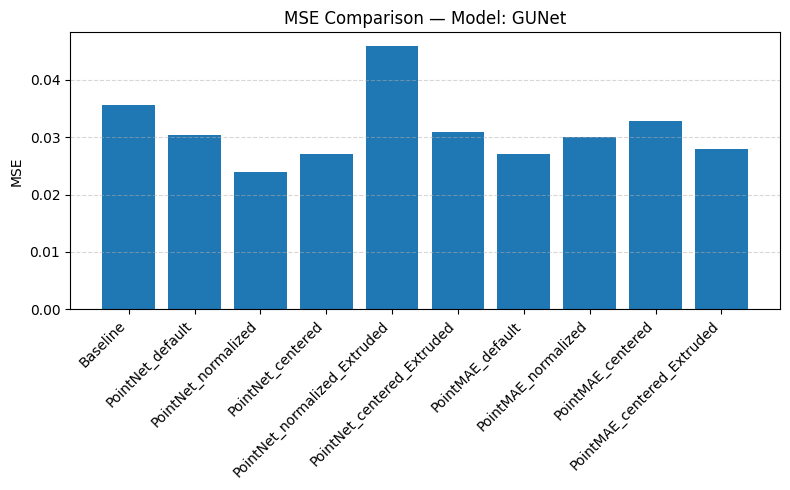

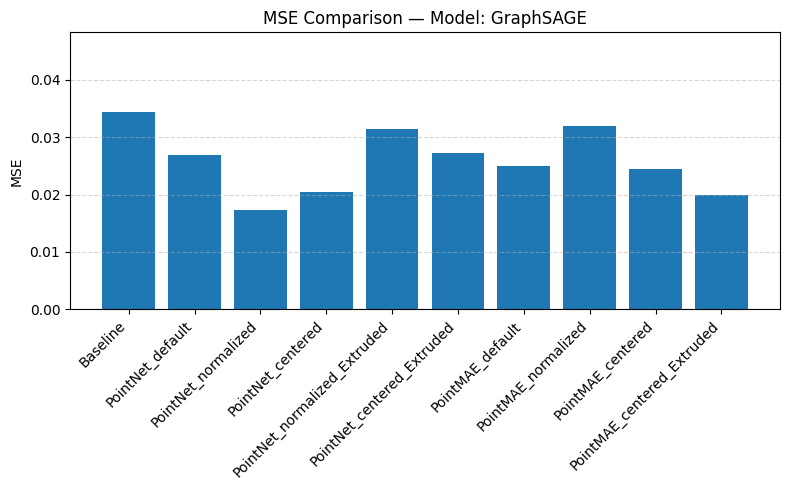

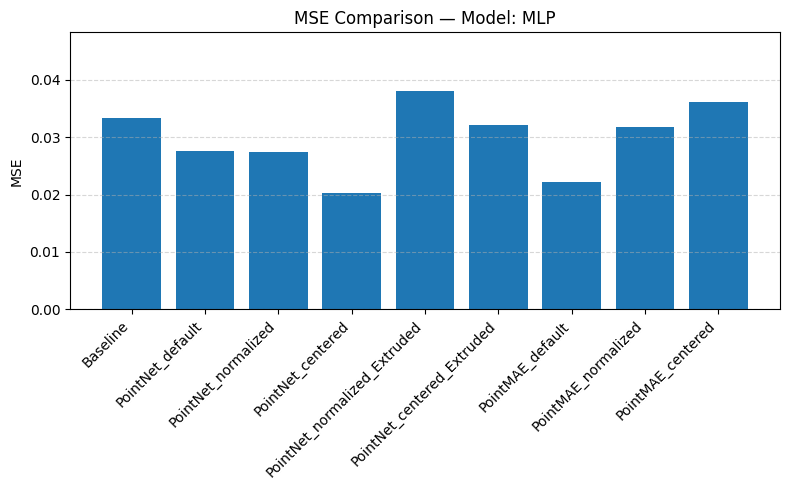

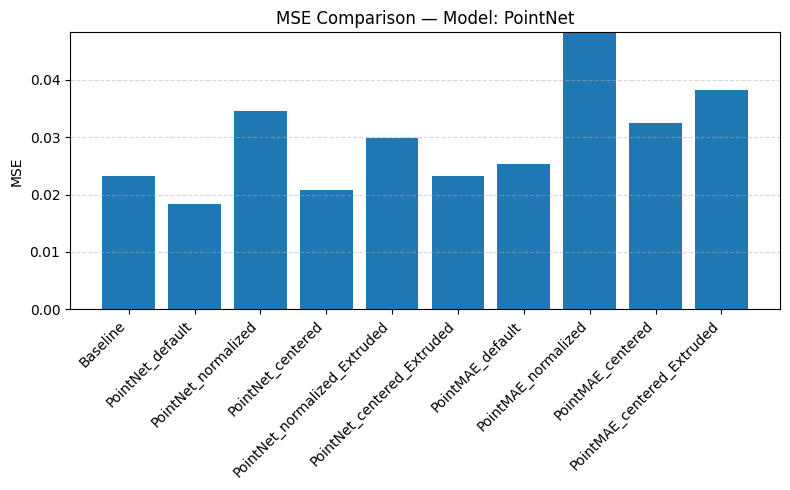

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------
# Compute metrics
# ---------------------------------------
def compute_metrics(model_path):
    files = os.listdir(model_path)

    if "pred_norm.npy" not in files or "true_norm.npy" not in files:
        return None

    true = np.load(os.path.join(model_path, "true_norm.npy"))
    pred = np.load(os.path.join(model_path, "pred_norm.npy"))

    mse  = np.mean((pred - true)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pred - true))

    return {"MSE": mse, "RMSE": rmse, "MAE": mae}


root = "."

# ---------------------------------------
# Condition parsing (robuste & rétro-compatible)
# ---------------------------------------
def detect_condition(folder_name):
    f = folder_name.lower()

    if "baseline" in f:
        return "Baseline"

    if "pointnet" in f:
        prefix = "PointNet"
    elif "pointmae" in f:
        prefix = "PointMAE"
    else:
        return None

    # --- OLD FORMAT ---
    if "default4" in f:
        return prefix + "_default"
    if "normalized4" in f:
        return prefix + "_normalized"
    if "centered4" in f:
        return prefix + "_centered"

    # --- NEW EXTRUDED FORMAT (case-insensitive) ---
    if "default_extruded" in f:
        return prefix + "_default_Extruded"
    if "normalized_extruded" in f:
        return prefix + "_normalized_Extruded"
    if "centered_extruded" in f:
        return prefix + "_centered_Extruded"

    # Unknown condition
    return None


# ---------------------------------------
# Scan all all_score folders
# ---------------------------------------
rows = []

for folder in os.listdir(root):
    if "all_score" not in folder:
        continue

    condition = detect_condition(folder)
    if condition is None:
        continue

    dataset_path = os.path.join(root, folder)

    for task in os.listdir(dataset_path):
        task_path = os.path.join(dataset_path, task)
        if not os.path.isdir(task_path):
            continue

        for model in os.listdir(task_path):
            model_path = os.path.join(task_path, model)
            if not os.path.isdir(model_path):
                continue

            metrics = compute_metrics(model_path)
            if metrics is None:
                continue

            rows.append({
                "Model": model,
                "Condition": condition,
                "MSE": metrics["MSE"]
            })

# ---------------------------------------
# DataFrame + Model normalization
# ---------------------------------------
df = pd.DataFrame(rows)

model_map = {
    "GraphSAGE": "GraphSAGE",
    "GraphSAGEGlobal": "GraphSAGE",
    "GUNet": "GUNet",
    "GUNetGlobal": "GUNet",
    "MLP": "MLP",
    "MLPGlobal": "MLP",
    "PointNet": "PointNet",
    "PointNetGlobal": "PointNet"
}

df["ModelUnified"] = df["Model"].map(model_map)
df = df.dropna(subset=["ModelUnified"])  # important

print(df)

# ---------------------------------------
# List complete of all possible conditions
# ---------------------------------------
conditions_order = [
    "Baseline",
    "PointNet_default",
    "PointNet_normalized",
    "PointNet_centered",
    "PointNet_default_Extruded",
    "PointNet_normalized_Extruded",
    "PointNet_centered_Extruded",
    "PointMAE_default",
    "PointMAE_normalized",
    "PointMAE_centered",
    "PointMAE_default_Extruded",
    "PointMAE_normalized_Extruded",
    "PointMAE_centered_Extruded",
]

# ---------------------------------------
# Plot
# ---------------------------------------
models = sorted(df["ModelUnified"].unique())
global_max = df["MSE"].max()

for model in models:

    data = (
        df[df["ModelUnified"] == model]
        .groupby("Condition")["MSE"]
        .mean()
        .reindex(conditions_order)
        .dropna()
    )

    plt.figure(figsize=(8,5))
    plt.bar(data.index, data.values)
    plt.ylabel("MSE")
    plt.title(f"MSE Comparison — Model: {model}")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.ylim(0, global_max)
    plt.tight_layout()
    plt.show()


In [7]:
'''import os
import json
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------
# 1) Lecture du JSON (val_loss)
# --------------------------------------------------------
def load_val_loss(model_path):
    # prend juste le premier JSON dans le dossier
    json_files = [f for f in os.listdir(model_path) if f.endswith(".json")]
    if not json_files:
        return None
    
    json_path = os.path.join(model_path, json_files[0])
    with open(json_path, "r") as f:
        data = json.load(f)

    return data.get("val_loss", None)


root = "."


# --------------------------------------------------------
# 2) Scan des dossiers all_metrics*
# --------------------------------------------------------
rows = []

for folder in os.listdir(root):
    if "all_metrics" not in folder:
        continue

    f = folder.lower()

    if   "baseline"   in f: condition = "Baseline"
    elif "pointnet"   in f and "default"    in f: condition = "PointNet_default"
    elif "pointnet"   in f and "normalized" in f: condition = "PointNet_normalized"
    elif "pointnet"   in f and "centered" in f: condition = "PointNet_centered"
    elif "pointmae"   in f and "default"    in f: condition = "PointMAE_default"
    elif "pointmae"   in f and "normalized" in f: condition = "PointMAE_normalized"
    elif "pointmae"   in f and "centered" in f: condition = "PointMAE_centered"
    else:
        continue
    dataset_path = os.path.join(root, folder)

    # tasks → models → JSON
    for task in os.listdir(dataset_path):
        task_path = os.path.join(dataset_path, task)
        if not os.path.isdir(task_path):
            continue

        for model in os.listdir(task_path):
            model_path = os.path.join(task_path, model)
            if not os.path.isdir(model_path):
                continue

            val_loss = load_val_loss(model_path)
            if val_loss is None:
                continue

            rows.append({
                "Model": model,
                "Condition": condition,
                "Val_Loss": val_loss
            })


# --------------------------------------------------------
# 3) DataFrame + unification des noms
# --------------------------------------------------------
df_val = pd.DataFrame(rows)

model_map = {
    "GraphSAGE": "GraphSAGE",
    "GraphSAGEGlobal": "GraphSAGE",
    "GUNet": "GUNet",
    "GUNetGlobal": "GUNet",
    "MLP": "MLP",
    "MLPGlobal": "MLP",
    "PointNet": "PointNet",
    "PointNetGlobal": "PointNet"
}

df_val["ModelUnified"] = df_val["Model"].map(model_map)

print(df_val)


# --------------------------------------------------------
# 4) Barplots par modèle
# --------------------------------------------------------
conditions_order = [
    "Baseline",
    "PointNet_default",
    "PointNet_normalized",
    "PointNet_centered",
    "PointMAE_default",
    "PointMAE_normalized",
    "PointMAE_centered"
]

models = sorted(df_val["ModelUnified"].unique())

# Same Y-axis scale for all plots
global_max = df_val["Val_Loss"].max()

for model in models:

    data = (
        df_val[df_val["ModelUnified"] == model]
        .groupby("Condition")["Val_Loss"]
        .mean()
        .reindex(conditions_order)
        .dropna()
    )

    plt.figure(figsize=(8,5))
    plt.bar(data.index, data.values)
    plt.ylabel("Validation Loss (MSE)")
    plt.title(f"Final Validation Loss — Model: {model}")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    # Fix the y-axis across all figures
    plt.ylim(0, global_max)

    plt.tight_layout()
    plt.show()'''

'import os\nimport json\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n\n# --------------------------------------------------------\n# 1) Lecture du JSON (val_loss)\n# --------------------------------------------------------\ndef load_val_loss(model_path):\n    # prend juste le premier JSON dans le dossier\n    json_files = [f for f in os.listdir(model_path) if f.endswith(".json")]\n    if not json_files:\n        return None\n\n    json_path = os.path.join(model_path, json_files[0])\n    with open(json_path, "r") as f:\n        data = json.load(f)\n\n    return data.get("val_loss", None)\n\n\nroot = "."\n\n\n# --------------------------------------------------------\n# 2) Scan des dossiers all_metrics*\n# --------------------------------------------------------\nrows = []\n\nfor folder in os.listdir(root):\n    if "all_metrics" not in folder:\n        continue\n\n    f = folder.lower()\n\n    if   "baseline"   in f: condition = "Baseline"\n    elif "pointnet"   in f and "def